# TP3 - Détection et Traitement des Outliers

**Difficulté:** Intermédiaire  
**Dataset:** sales_outliers.csv  
**Description:** Identification des valeurs aberrantes avec méthodes statistiques

---


## Imports des Bibliothèques


In [195]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [196]:
# Charger le dataset
df = pd.read_csv('../data/sales_outliers.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 1020 lignes × 4 colonnes
 Taille mémoire: 0.12 MB




,transaction_id,amount,product,date
0,1,1458.56,B,2023-01-01
1,2,4399.43,B,2023-01-02
2,3,1298.67,C,2023-01-03
3,4,1580.76,A,2023-01-04
4,5,946.03,C,2023-01-05




<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1020 non-null   int64  
 1   amount          1020 non-null   float64
 2   product         1020 non-null   str    
 3   date            1020 non-null   str    
dtypes: float64(1), int64(1), str(2)
memory usage: 32.0 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

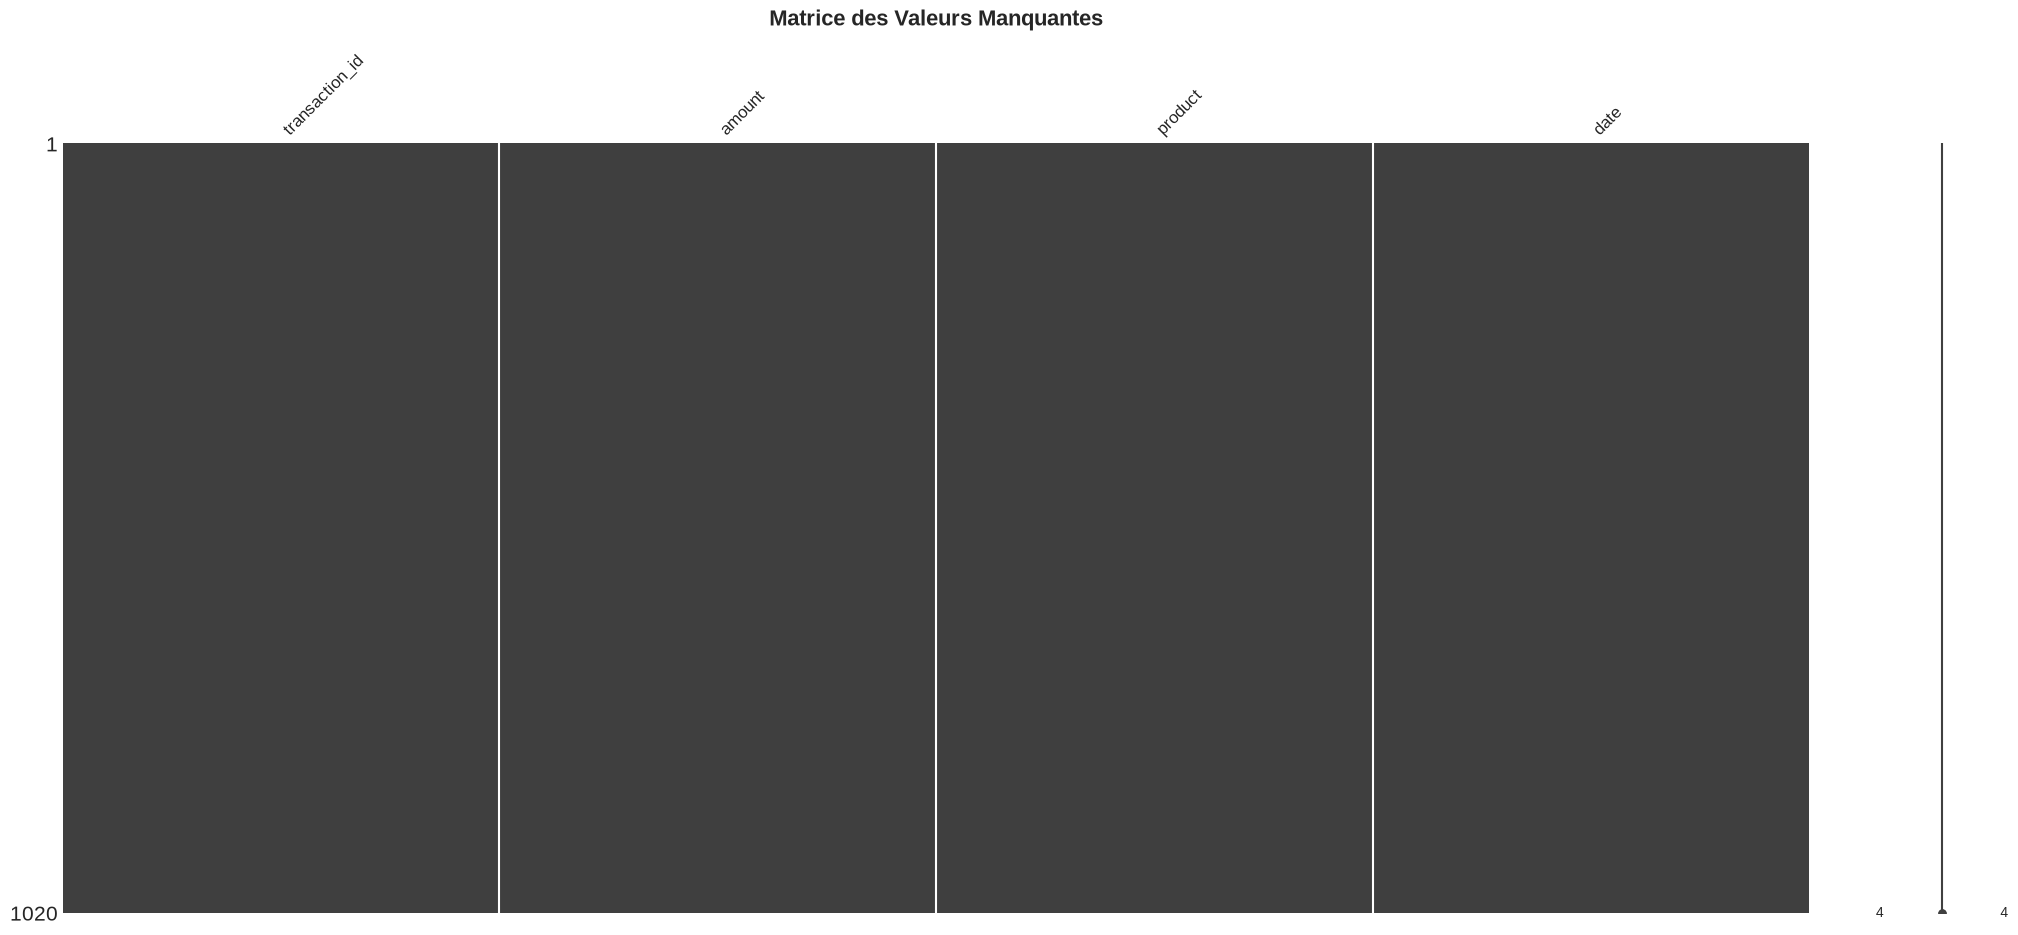


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [197]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quelle est la distribution de la colonne 'amount' ?
2. Y a-t-il des valeurs négatives dans les montants ?
3. Quel est le montant maximum et semble-t-il aberrant ?
4. Combien d'outliers détecte la méthode IQR pour 'amount' ?
5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?
6. Les deux méthodes identifient-elles les mêmes outliers ?
7. Quelle proportion du dataset représentent les outliers ?
8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?
10. Comment la moyenne change-t-elle après traitement des outliers ?


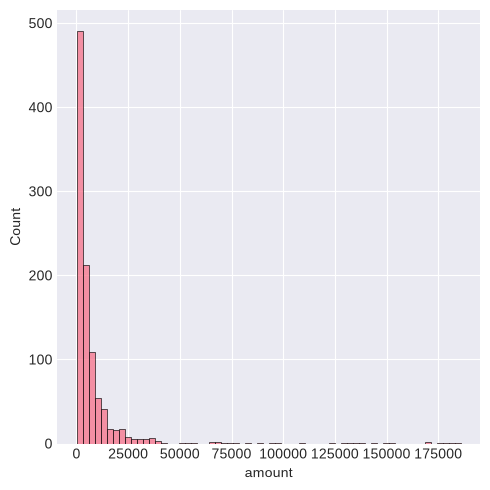

In [198]:
#1. Quelle est la distribution de la colonne 'amount' ?
df.amount.describe()
sns.displot(df.amount)

In [199]:
#2. Y a-t-il des valeurs négatives dans les montants ?
df.amount.min()

np.float64(79.57)

In [200]:
#3. Quel est le montant maximum et semble-t-il aberrant ?
df.amount.max()

np.float64(185913.06)

In [201]:
#4. Combien d'outliers détecte la méthode IQR pour 'amount' ?
# Détection par IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Utilisation
outliers, lower, upper = detect_outliers_iqr(df, 'amount')
print(f"Nombre d'outliers: {len(outliers)}")
print(f"Limites: [{lower:.2f}, {upper:.2f}]")

Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]


In [202]:
#5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?

from scipy import stats

z_scores = np.abs(stats.zscore(df["amount"]))
threshold = 3

outliers = df[z_scores > threshold]
print(f"outliers détectés: {len(outliers)}")

outliers détectés: 22


In [203]:
#6. Les deux méthodes identifient-elles les mêmes outliers ?
#non

In [204]:
df

,transaction_id,amount,product,date
0,1,1458.56,B,2023-01-01
1,2,4399.43,B,2023-01-02
2,3,1298.67,C,2023-01-03
3,4,1580.76,A,2023-01-04
4,5,946.03,C,2023-01-05
...,...,...,...,...
1015,1016,1862.90,C,2025-10-12
1016,1017,452.57,C,2025-10-13
1017,1018,4786.74,B,2025-10-14
1018,1019,7412.97,C,2025-10-15


In [205]:
#7. Quelle proportion du dataset représentent les outliers ?
df.amount.shape
print(f"méthode IQR: {round(105 * 100 / df.amount.shape[0], 2)}%")
print(f"méthode z-score: {round(22 * 100 / df.amount.shape[0], 2)}%")

méthode IQR: 10.29%
méthode z-score: 2.16%


<Axes: xlabel='product', ylabel='amount'>

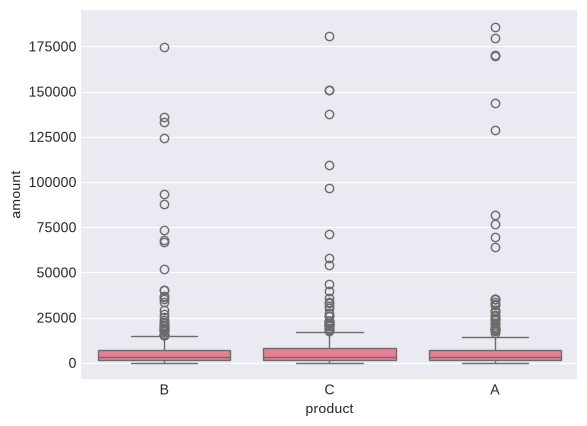

In [206]:
#8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
#non

sns.boxplot(data = df, x = "product", y = "amount")

In [207]:
#9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?
#trops peux d'informations, par contre il est peux propable que ce sois des erreurs de saisie car trop nombreuses 

In [208]:
#10. Comment la moyenne change-t-elle après traitement des outliers ?
df_clean = df.copy()
upper = df.amount.quantile(0.9)
df_clean["amount"] = df["amount"].clip(upper=upper)
print(f"moyenne avant le traitement {df.amount.mean().round(2)}")
print(f"moyenne après le traitement {df_clean.amount.mean().round(2)}")
# sns.boxplot(data = df_clean, x = "product", y = "amount")

moyenne avant le traitement 8616.96
moyenne après le traitement 5213.52


In [209]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici


Réponses aux questions:


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Visualiser la distribution avec boxplot et histogramme
### Étape 2: Calculer les statistiques descriptives
### Étape 3: Implémenter la détection par méthode IQR
### Étape 4: Implémenter la détection par Z-score
### Étape 5: Comparer les résultats des deux méthodes
### Étape 6: Décider d'une stratégie: suppression ou capping
### Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
### Étape 8: Visualiser la distribution avant/après traitement
### Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
### Étape 10: Documenter les outliers traités dans un rapport


 Étape 1 complétée


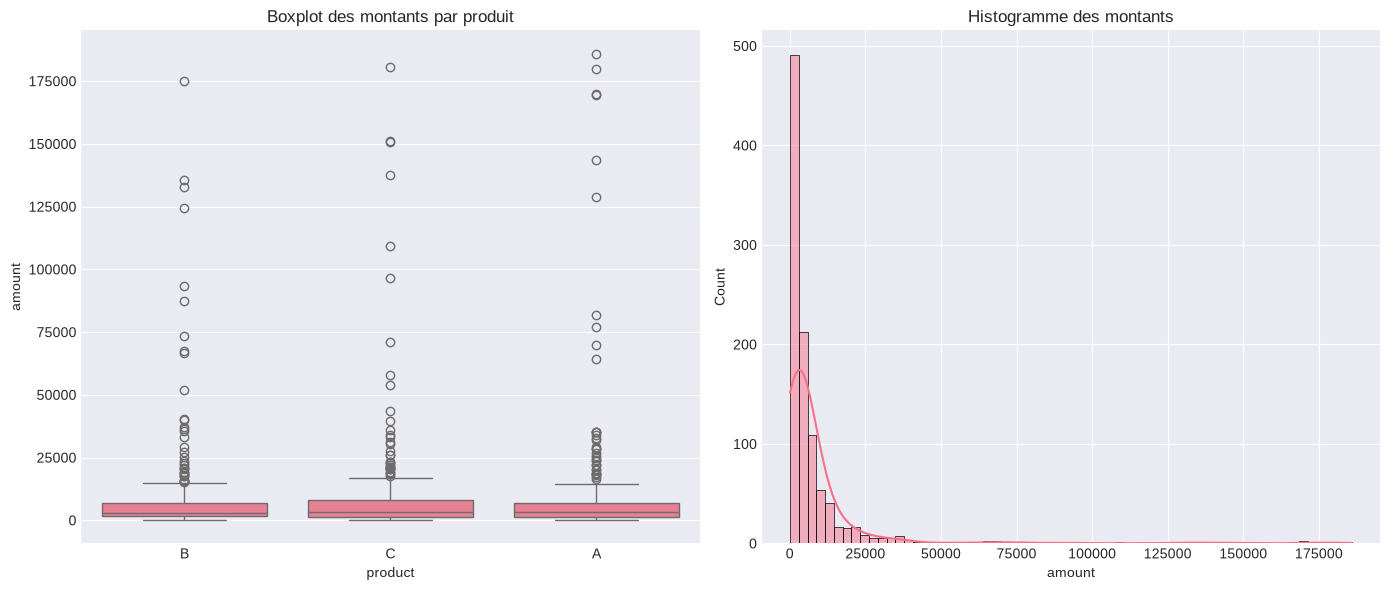

In [210]:
# ========================================
# Étape 1: Visualiser la distribution avec boxplot et histogramme
# ========================================

# TODO: Écrivez votre code ici
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x="product", y="amount", ax=axes[0])
sns.histplot(data=df, x="amount", kde=True, ax=axes[1])

axes[0].set_title("Boxplot des montants par produit")
axes[1].set_title("Histogramme des montants")
plt.tight_layout()

# Vérification
print(f" Étape 1 complétée")

In [211]:
# ========================================
# Étape 2: Calculer les statistiques descriptives
# ========================================

# TODO: Écrivez votre code ici
display(df.describe())

# Vérification
print(f" Étape 2 complétée")

,transaction_id,amount
count,1020.00,1020.00
mean,510.50,8616.96
std,294.59,20525.04
min,1.00,79.57
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,185913.06


 Étape 2 complétée


In [212]:
# ========================================
# Étape 3: Implémenter la détection par méthode IQR
# ========================================

# TODO: Écrivez votre code ici

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers_iqr, lower_bound, upper_bound

outliers_iqr, lower, upper = detect_outliers_iqr(df, "amount")
print(f"Nombre d'outliers: {len(outliers_iqr)}")
print(f"Limites: [{lower:.2f}, {upper:.2f}]")


# Vérification
print(f" Étape 3 complétée")

Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]
 Étape 3 complétée


In [213]:
# ========================================
# Étape 4: Implémenter la détection par Z-score
# ========================================

# TODO: Écrivez votre code ici
z_scores = np.abs(stats.zscore(df["amount"]))
threshold = 3

outliers_zscore = df[z_scores > threshold]
print(f"Outliers détectés: {len(outliers_zscore)}")

# Vérification
print(f" Étape 4 complétée")

Outliers détectés: 22
 Étape 4 complétée


In [214]:
# ========================================
# Étape 5: Comparer les résultats des deux méthodes
# ========================================

# TODO: Écrivez votre code ici

# détection par méthode IQR = 105
# détection par Z-score = 22

# Vérification
print(f" Étape 5 complétée")

 Étape 5 complétée


In [215]:
# ========================================
# Étape 6: Décider d'une stratégie: suppression ou capping
# ========================================

# TODO: Écrivez votre code ici

#capping parce que valeur légitime

# Vérification
print(f" Étape 6 complétée")

 Étape 6 complétée


In [216]:
# ========================================
# Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
# ========================================

# TODO: Écrivez votre code ici
df_clean = df.copy()
upper = df.amount.quantile(0.9)
df_clean["amount"] = df["amount"].clip(upper=upper)
print(f"moyenne avant le traitement {df.amount.mean().round(2)}")
print(f"moyenne après le traitement {df_clean.amount.mean().round(2)}")

# Vérification
print(f" Étape 7 complétée")

moyenne avant le traitement 8616.96
moyenne après le traitement 5213.52
 Étape 7 complétée


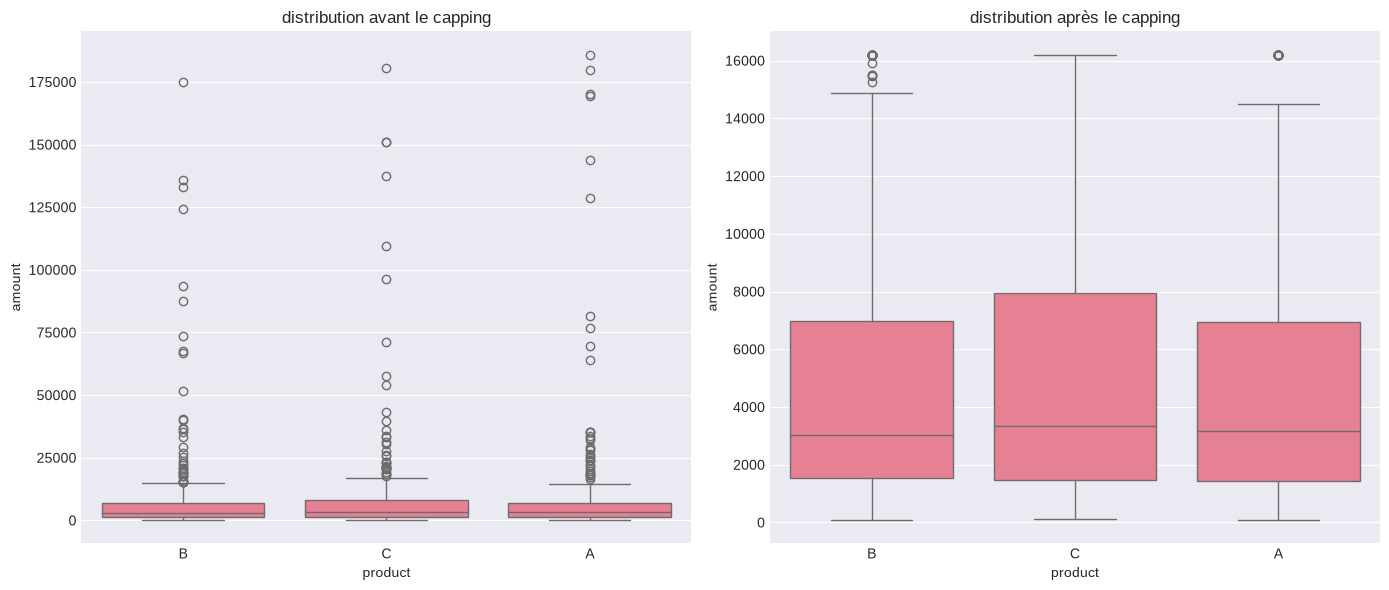

In [217]:
# ========================================
# Étape 8: Visualiser la distribution avant/après traitement
# ========================================

# TODO: Écrivez votre code ici

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(df, x="product", y="amount", ax=axes[0])
sns.boxplot(df_clean, x="product", y="amount", ax=axes[1])

axes[0].set_title("distribution avant le capping")
axes[1].set_title("distribution après le capping")
plt.tight_layout()

# Vérification
# print(f" Étape 8 complétée")

In [218]:
# ========================================
# Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
# ========================================

# TODO: Écrivez votre code ici
display(df.describe())
display(df_clean.describe())
print(f"la moyenne avant le traitement: {df.amount.mean().round(2)}")
print(f"la moyenne après le traitement: {df_clean.amount.mean().round(2)}")
print(f"sois une réduction de la moyenne de: {100 - (df_clean.amount.mean() * 100 / df.amount.mean()).round(2)}%")
print()
print(f"l'écart type avant le traitement: {df.amount.std().round(2)}")
print(f"l'écart type après le traitement: {df_clean.amount.std().round(2)}")
print(f"sois une réduction de l'écart type de: {100 - (df_clean.amount.std() *100 / df.amount.std()).round(2)}%")

# Vérification
print(f" Étape 9 complétée")

,transaction_id,amount
count,1020.00,1020.00
mean,510.50,8616.96
std,294.59,20525.04
min,1.00,79.57
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,185913.06


,transaction_id,amount
count,1020.00,1020.00
mean,510.50,5213.52
std,294.59,4991.00
min,1.00,79.57
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,16208.22


la moyenne avant le traitement: 8616.96
la moyenne après le traitement: 5213.52
sois une réduction de la moyenne de: 39.5%

l'écart type avant le traitement: 20525.04
l'écart type après le traitement: 4991.0
sois une réduction de l'écart type de: 75.68%
 Étape 9 complétée


In [219]:
# ========================================
# Étape 10: Documenter les outliers traités dans un rapport
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 10 complétée")

 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [220]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df_clean.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': df.shape[0] - df_clean.shape[0],
    'Colonnes_supprimées': df.shape[1] - df_clean.shape[1],
    'Valeurs_manquantes_traitées': df.isna().sum().sum() - df_clean.isna().sum().sum(),
    'Doublons_supprimés': df.duplicated().sum() - df_clean.duplicated().sum(),
    'Outliers_traités': len(outliers_iqr),
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n✅ TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (1020, 4)
Dimensions_finales...................... (1020, 4)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 105
Transformations_appliquées.............. []

✅ TP terminé avec succès!
